# 3 - Extensión opcional del pipeline mediante evidencia visual

Hasta este punto, el sistema desarrollado dispone de los componentes necesarios para procesar una incidencia urbana reportada en formato textual, permitiendo obtener dos tipos de información fundamentales:

* Clasificación temática de la incidencia, que permite identificar la categoría del problema reportado (por ejemplo, residuos, alumbrado, baches, mobiliario urbano, señalización, entre otros).

* Análisis de sentimiento mediante BETO, que permite estimar la carga emocional del mensaje y detectar posibles situaciones de insatisfacción, urgencia o frustración por parte del ciudadano.

Estos dos módulos constituyen el núcleo del pipeline de procesamiento de incidencias y permiten automatizar gran parte de la interpretación inicial del reporte. No obstante, en escenarios reales de participación ciudadana es frecuente que los usuarios adjunten fotografías como complemento al texto, con el objetivo de mostrar de forma directa el estado de la vía pública o del elemento afectado.

Por este motivo, en este notebook se introduce de forma opcional un tercer componente orientado al aprovechamiento de información visual:

* Descripción automática de imágenes (Image-to-Text o Image Captioning), cuyo objetivo es transformar la fotografía en una representación textual que pueda ser utilizada por los módulos posteriores del sistema.

La inclusión de información visual se justifica por varios factores relevantes para el tratamiento de incidencias urbanas:

* Reducción de ambigüedad del mensaje: en muchos casos, el texto aportado por el usuario puede ser breve, poco específico o contener expresiones coloquiales que dificultan la identificación exacta del problema.

* Aumento del contexto disponible: la imagen puede mostrar el entorno urbano (acera, calzada, parque, fachada), lo que facilita la interpretación del tipo de infraestructura afectada.

* Mejor comprensión del estado del elemento reportado: el grado de deterioro, acumulación o daño puede ser más evidente en la imagen que en el texto.

* Mejora potencial en la calidad de la respuesta del sistema: disponer de más contexto permite generar respuestas más ajustadas, específicas y alineadas con la situación real observada.

En este sentido, la imagen no se considera una fuente independiente de decisión, sino una señal complementaria que enriquece la información ya obtenida a partir del texto.

Desde el punto de vista del diseño del sistema, este módulo visual se integra de manera que no altera el funcionamiento original del pipeline:

* Cuando no existe imagen adjunta, el sistema opera exclusivamente con los módulos textuales (clasificación temática y análisis de sentimiento), manteniendo exactamente el mismo comportamiento que en las secciones anteriores del proyecto.

* Cuando el usuario adjunta una imagen, se activa un paso adicional de procesamiento que genera una descripción textual de dicha imagen, la cual se incorpora posteriormente al contexto que recibirá el agente LLM.

Este enfoque permite que el sistema sea robusto ante distintos tipos de entrada, evitando dependencias estrictas del componente visual y garantizando que la ausencia de imagen no degrada el funcionamiento general del sistema.


Antes de aplicar cualquier modelo de procesamiento visual, es necesario comprobar que las imagenes han sido correctamente cargadas y son accesibles para el sistema. Por ello, en esta sección se realiza una carga explícita del archivo de imagen y se muestra su contenido.

Este paso cumple dos funciones principales:

* Verificar que la ruta del archivo y el formato son correctos, evitando errores en las etapas posteriores.

* Permitir una inspección visual que facilite la interpretación de los resultados que se obtendrán más adelante durante la generación de descripciones automáticas.

A continuación, se muestran la imagenes de ejemplo que se utilizarán para simular una incidencia relacionada con el ámbito de los residuos urbanos.

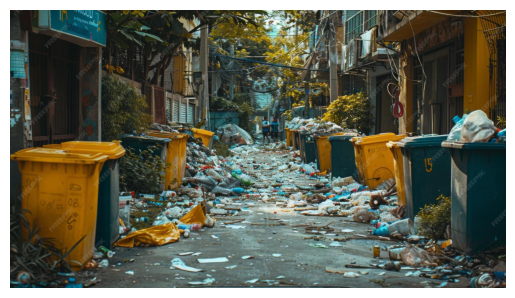

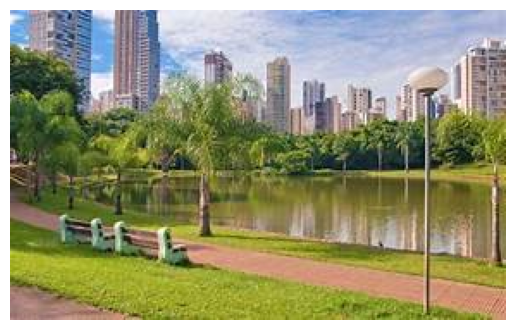

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "../data/imagenes/basura.avif"
image = Image.open(img_path).convert("RGB")
plt.figure()
plt.imshow(image)
plt.axis("off")
plt.show()

img_path_2 = "../data/imagenes/parque_bonito.jpg"
image_2 = Image.open(img_path_2).convert("RGB")
plt.figure()
plt.imshow(image_2)
plt.axis("off")
plt.show()


**Generación automática de descripciones mediante Image Captioning**

Una vez que las imágenes han sido correctamente cargadas y verificadas, el siguiente paso consiste en aplicar un modelo de image captioning con el objetivo de generar una representación textual automática del contenido visual. Esta transformación de imagen a texto permite que la información visual pueda ser tratada posteriormente por los mismos componentes de procesamiento lingüístico utilizados en el resto del sistema.

En este trabajo se emplea el modelo BLIP (Bootstrapping Language–Image Pretraining), un modelo multimodal entrenado para aprender correspondencias entre imágenes y lenguaje natural, y que ha mostrado un buen desempeño en tareas de generación de descripciones, recuperación multimodal y alineación visión–lenguaje. El uso de un modelo preentrenado permite incorporar capacidades de percepción visual sin necesidad de disponer de un conjunto de datos específico de incidencias urbanas para el entrenamiento desde cero.

Es importante destacar que este módulo no tiene como finalidad sustituir a los mecanismos de clasificación existentes ni realizar por sí mismo la determinación del tipo de incidencia. Su función principal es actuar como un mecanismo de enriquecimiento del contexto, proporcionando al agente LLM una descripción adicional que pueda ser utilizada como apoyo durante el razonamiento y la generación de respuestas.

In [7]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
captioner = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print(f"BLIP cargado en: {device}")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP cargado en: cuda


La salida del modelo de image captioning consiste en una o varias frases en lenguaje natural que describen los elementos principales presentes en la imagen y su contexto general. Estas descripciones suelen mencionar objetos, escenas y relaciones espaciales de forma sintética, lo cual resulta adecuado para ser incorporado directamente como parte del contexto textual de entrada al agente LLM.

Posteriormente, esta información será integrada en una estructura de datos unificada junto con las demás señales del sistema, permitiendo que el agente utilice la descripción visual durante la generación de la respuesta, la solicitud de información adicional o la priorización de la incidencia.

In [8]:
def describe_image(image):
    inputs = processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = captioner.generate(**inputs)
    return processor.decode(out[0], skip_special_tokens=True)

print(describe_image(image))
print(describe_image(image_2))

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

garbage bins in a street
a park with a bench and a lake


/home/salmags/Documentos/master_IA/procesamiento_lenguaje_natural/urban-complaints-nlp/venv_test/lib/python3.12/site-packages/transformers/generation/utils.py:1551: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [ ]:
def describe_image(image):
    inputs = processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = captioner.generate(**inputs)
    return processor.decode(out[0], skip_special_tokens=True)

print(describe_image(image))

garbage bins in a street
a park with a bench and a lake


En la siguiente celda se ejecuta el modelo BLIP sobre la imagen previamente cargada, correspondiente a una incidencia simulada en el ámbito de los parques. El objetivo es observar el tipo de descripción generada y evaluar en qué medida la información visual puede complementar el contenido textual del reporte.

In [10]:
print(describe_image(image_2))

a park with a bench and a lake
